### Import packages

In [38]:
import numpy as np
import pyrleam as RLEAM
import pandas as pd
import copy
from tqdm import tqdm
import random
import matplotlib.pyplot as plt
import ssms
from ssms.basic_simulators.simulator import simulator

### Helper function

In [24]:
def Generate_trials(task):
    """Function to generate trials with random order
    """
    
    n_trials = task['n_trials']
    
    if (n_trials % 10 == 0):
        factor = int(n_trials/10)
    else:
        print("Error: The number of trials (n_trials) must be a multiple of 10")
    
    class_2_options = task['trial_class']['trials_2_options']
    class_3_options = task['trial_class']['trials_3_options']

    class_2_list = class_2_options * factor
    class_3_list = class_3_options * factor

    joint_list = class_2_list + class_3_list

    shuffled_array = random.sample(joint_list, len(joint_list))

    trial_type = np.zeros((n_trials,2))

    for i in range(n_trials):
        arr = shuffled_array[i]
        if len(arr) == 2:
            trial_type[i,0] = 2
            for j in range(len(class_2_options)):
                if arr == class_2_options[j]:
                    trial_type[i,1] = j

        if len(arr) == 3:
            trial_type[i,0] = 3
            for j in range(len(class_3_options)):
                if arr == class_3_options[j]:
                    trial_type[i,1] = j


    return trial_type

In [25]:
"""
data = pd.read_csv('data.csv')

#Get option 1 rewards
option_1_rewards = data[(data['participant'] == 1) & (data['inc_option'] == 1) & (data['block_label']==0.0)]['f_inc']
option_1_rewards = [int(x) for x in list(option_1_rewards.values)]


#Get option 2 rewards
cor_2_rewards = data[(data['participant'] == 1) & (data['cor_option'] == 2) & (data['block_label']==0.0)]['f_cor']
inc_2_rewards = data[(data['participant'] == 1) & (data['inc_option'] == 2) & (data['block_label']==0.0)]['f_inc']

inc_2_rewards = [int(x) for x in list(inc_2_rewards.values)]
cor_2_rewards = [int(x) for x in list(cor_2_rewards.values)]

option_2_rewards = inc_2_rewards + cor_2_rewards

#Get option 3 rewards
cor_3_rewards = data[(data['participant'] == 1) & (data['cor_option'] == 3) & (data['block_label']==0.0)]['f_cor']
inc_3_rewards = data[(data['participant'] == 1) & (data['inc_option'] == 3) & (data['block_label']==0.0)]['f_inc']

inc_3_rewards = [int(x) for x in list(inc_3_rewards.values)]
cor_3_rewards = [int(x) for x in list(cor_3_rewards.values)]

option_3_rewards = inc_3_rewards + cor_3_rewards

#Get option 4 rewards
option_4_rewards = data[(data['participant'] == 1) & (data['cor_option'] == 4) & (data['block_label']==0.0)]['f_cor']
option_4_rewards= [int(x) for x in list(option_4_rewards.values)]
"""

"\ndata = pd.read_csv('data.csv')\n\n#Get option 1 rewards\noption_1_rewards = data[(data['participant'] == 1) & (data['inc_option'] == 1) & (data['block_label']==0.0)]['f_inc']\noption_1_rewards = [int(x) for x in list(option_1_rewards.values)]\n\n\n#Get option 2 rewards\ncor_2_rewards = data[(data['participant'] == 1) & (data['cor_option'] == 2) & (data['block_label']==0.0)]['f_cor']\ninc_2_rewards = data[(data['participant'] == 1) & (data['inc_option'] == 2) & (data['block_label']==0.0)]['f_inc']\n\ninc_2_rewards = [int(x) for x in list(inc_2_rewards.values)]\ncor_2_rewards = [int(x) for x in list(cor_2_rewards.values)]\n\noption_2_rewards = inc_2_rewards + cor_2_rewards\n\n#Get option 3 rewards\ncor_3_rewards = data[(data['participant'] == 1) & (data['cor_option'] == 3) & (data['block_label']==0.0)]['f_cor']\ninc_3_rewards = data[(data['participant'] == 1) & (data['inc_option'] == 3) & (data['block_label']==0.0)]['f_inc']\n\ninc_3_rewards = [int(x) for x in list(inc_3_rewards.value

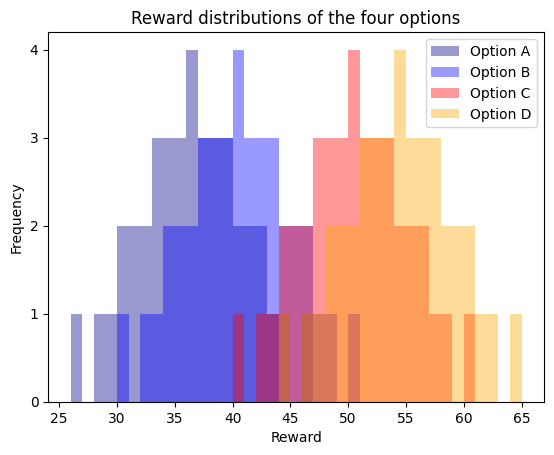

In [26]:
option_A_rewards = [26, 28, 29, 30, 30, 31, 31, 32, 32, 33, 
                    33, 33, 34, 34, 34, 35, 35, 35, 36, 36,
                    36, 36, 37, 37, 37, 38, 38, 38, 39, 39, 
                    39, 40, 40, 41, 41, 42, 42, 43, 44, 46]

option_B_rewards = [30, 32, 33, 34, 34, 35, 35, 36, 36, 37, 
                    37, 37, 38, 38, 38, 39, 39, 39, 40, 40, 
                    40, 40, 41, 41, 41, 42, 42, 42, 43, 43, 
                    43, 44, 44, 45, 45, 46, 46, 47, 48, 50]

option_C_rewards = [40, 42, 43, 44, 44, 45, 45, 46, 46, 47, 
                    47, 47, 48, 48, 48, 49, 49, 49, 50, 50, 
                    50, 50, 51, 51, 51, 52, 52, 52, 53, 53, 
                    53, 54, 54, 55, 55, 56, 56, 57, 58, 60]

option_D_rewards = [44, 46, 47, 48, 48, 49, 49, 50, 50, 51, 
                    51, 51, 52, 52, 52, 53, 53, 53, 54, 54, 
                    54, 54, 55, 55, 55, 56, 56, 56, 57, 57, 
                    57, 58, 58, 59, 59, 60, 60, 61, 62, 64]

#Define bins
bins_A = list(range(min(option_A_rewards), max(option_A_rewards) + 2))
bins_B = list(range(min(option_B_rewards), max(option_B_rewards) + 2))
bins_C = list(range(min(option_C_rewards), max(option_C_rewards) + 2))
bins_D = list(range(min(option_D_rewards), max(option_D_rewards) + 2))


#Plot histogram
plt.hist(option_A_rewards, bins = bins_A, alpha = 0.4,label = "Option A", color = "darkblue")
plt.hist(option_B_rewards, bins = bins_B, alpha = 0.4,label = "Option B", color = "blue")
plt.hist(option_C_rewards, bins = bins_C, alpha = 0.4,label = "Option C", color = "red")
plt.hist(option_D_rewards, bins = bins_D, alpha = 0.4,label = "Option D", color = "orange")

plt.locator_params(axis='y', integer=True)
plt.title("Reward distributions of the four options")
plt.ylabel("Frequency")
plt.xlabel("Reward")
plt.legend()
plt.show()

## Define the task and the agent

In [27]:
# Generate trials

#Define number of trials


#task = {
#    "n_trials": 140,
#    "option_1_rewards": option_A_rewards,
#    "option_2_rewards": option_B_rewards,
#    "option_3_rewards": option_C_rewards,
#    "option_4_rewards": option_D_rewards,
#    "trial_class": {
#        "trials_2_options": [[1,4],[1,3],[2,4],[2,3],[1,2],[3,4]], 
#        "trials_3_options": [[1,3,4],[2,3,4],[1,2,3],[1,2,4]]
#    },
#    "experiment_trials": [],
#    "desired_subj_times": np.ones(n_trials)*4,
#    "obj_times": np.ones(n_trials)*7#10
#}


#metadata = {
#    "eam_model": "lca",
#    "drift_rate_model": "q_vanilla",
#    "n_par": 1
#}

#agent = {
#    'theta' : {
#        'v_mod': 0.01,
#        'v_mod_eng': [0.019,0.01,0.001],#[0.015,0.01,0.005],
#        'a': 1,
#        'lr': 0.09,
#        'ndt': 0.3,
#        'leak': -0.5,
#        'inh': -1.5,
#        'offset':0.1,
#        'noise_std': 0.1,
#        'clock_ratio_load': 0.9,
#        'clock_ratio_idle': 1.1,  
#    },
#    'state': {
#        'q_vals': np.zeros((n_trials,4)),
#        'rts': np.zeros(n_trials),
#        'choices': np.zeros(n_trials),
#        'eng_levels': np.zeros(n_trials),
#        'subj_times': np.zeros(n_trials),
#        'correct_choice': np.zeros(n_trials),
#        'pred_error': np.zeros(n_trials),
#        'best_minus_second_best': np.zeros(n_trials) 
#    }
#}

#controller = {
#    'n_controller_sims': 10,
#    'perf_cutoff': 0.7#0.7
#}

In [41]:
n_trials = 60
num_par = 50

task = {
    "n_trials": n_trials,
    "option_1_rewards": option_A_rewards,
    "option_2_rewards": option_B_rewards,
    "option_3_rewards": option_C_rewards,
    "option_4_rewards": option_D_rewards,
    "trial_class": {
        "trials_2_options": [[1,4],[1,3],[2,4],[2,3],[1,2],[3,4]], 
        "trials_3_options": [[1,3,4],[2,3,4],[1,2,3],[1,2,4]]
    },
    "experiment_trials": [],
    "desired_subj_times": np.ones(n_trials)*4,
    "obj_times": np.ones(n_trials)*7#10
}


metadata = {
    "eam_model": "race",#"lca",
    "drift_rate_model": "q_mean",
    "learning_model": "delta",
    "n_par": 1
}


agent = {
    'theta': {
        'lca': {
            'a': 1,
            'ndt': 0.3,
            'leak': -0.5,
            'inh': -1.5,#-1.3,
            'offset':0.1,
            'noise_std': 0.1,      
        },
        'race': {
            'ndt': 0.3,
            'a': 2.5
        },
        
        'q_mean': {
            'v_mod': 0.01,
            'v_mod_eng': [0.019,0.01,0.005]#[0.019,0.01,0.001],       
        },
        
        'delta': {
            'lr': 0.09,
        },  
        
        'q_cv': {
            'v_mod': 0.01,
            'v_mod_eng': [0.015,0.01,0.005],       
        },
    
        'q_cv_unc_bonus': {
            'alpha': 0.005,
            'beta': 0.005
        },

        'bmt': {
            'prior_means':[0,0,0,0],
            'prior_vars':[1000,1000,1000,1000],
            'error_vars': [25,25,25,25]
        },
        
        'clock':{
             'clock_ratio_load': 0.9,
             'clock_ratio_idle': 1.1,
        }
    },
    
    'state': {
        'q_vals': np.zeros((n_trials,4)),
        'rts': np.zeros(n_trials),
        'choices': np.zeros(n_trials),
        'eng_levels': np.zeros(n_trials),
        'subj_times': np.zeros(n_trials),
        'correct_choice': np.zeros(n_trials),
        'pred_error': np.zeros(n_trials),
        'best_minus_second_best': np.zeros(n_trials) 
    }
   
}


controller = {
    'n_controller_sims': 5,
    'perf_cutoff': 0.7#0.7
}


In [42]:
experiment_trials = []

for p in range(metadata['n_par']):
    experiment_trials.append(Generate_trials(task))
    
task['experiment_trials'] = experiment_trials

In [43]:
def PredictSubjectiveTime(agent, task, trial):
    
    rt = agent['state']['rts'][trial]
    
    #clock_ratio (subjective_second per second)
    clock_ratio_load = agent['theta']['clock']['clock_ratio_load']
    clock_ratio_idle = agent['theta']['clock']['clock_ratio_idle']
    
    obj_time_int = task['obj_times'][trial]
    
    subj_time_int = rt*clock_ratio_load + (obj_time_int - rt)*clock_ratio_idle
    
    return subj_time_int

In [44]:
def Controller(controller, agent, task, trial):
    
    # Number of predicted samples for the controller
    n_controller_sims = controller['n_controller_sims']
    # Performance cutoff
    cutoff = controller['perf_cutoff']
    
    # Get the desired subjective time for this trial
    desired_subj_time = task['desired_subj_times'][trial]
    
    #Intialize empty lists
    pred_rts_eng_level_0 = np.zeros(n_controller_sims)
    pred_rts_eng_level_1 = np.zeros(n_controller_sims)
    pred_rts_eng_level_2 = np.zeros(n_controller_sims)

    pred_correct_choices_eng_level_0 = np.zeros(n_controller_sims)
    pred_correct_choices_eng_level_1 = np.zeros(n_controller_sims)
    pred_correct_choices_eng_level_2 = np.zeros(n_controller_sims)
    
    for n in range(n_controller_sims):
    
        #Predict rt and performance for engagement level 0
        sim_out_eng_0 = rleam_model.simulate_trial(agent_state = agent['state'], 
                                                   eng_level = 0, trial = trial)
        
        #Predict rt and performance for engagement level 1
        sim_out_eng_1 = rleam_model.simulate_trial(agent_state = agent['state'], 
                                                   eng_level = 1, trial = trial)
        
        #Predict rt and performance for engagement level 2
        sim_out_eng_2 = rleam_model.simulate_trial(agent_state = agent['state'], 
                                                   eng_level = 2, trial = trial)
        
        #Store predicted reaction times and whether the correct option was selected
        pred_rts_eng_level_0[n] = sim_out_eng_0['rt']
        pred_rts_eng_level_1[n] = sim_out_eng_1['rt']
        pred_rts_eng_level_2[n] = sim_out_eng_2['rt']
    
        pred_correct_choices_eng_level_0[n] = sim_out_eng_0['correct_choice']
        pred_correct_choices_eng_level_1[n] = sim_out_eng_1['correct_choice']
        pred_correct_choices_eng_level_2[n] = sim_out_eng_2['correct_choice']
        
    #Compute the average predicted rts
    mean_pred_rt_eng_level_0 = np.average(pred_rts_eng_level_0)
    mean_pred_rt_eng_level_1 = np.average(pred_rts_eng_level_1)
    mean_pred_rt_eng_level_2 = np.average(pred_rts_eng_level_2)
    
    #Fraction correct predicted choices
    fract_correct_eng_level_0 = np.sum(pred_correct_choices_eng_level_0)/n_controller_sims
    fract_correct_eng_level_1 = np.sum(pred_correct_choices_eng_level_1)/n_controller_sims
    fract_correct_eng_level_2 = np.sum(pred_correct_choices_eng_level_2)/n_controller_sims
    
    pred_agent_eng_level_0 = copy.deepcopy(agent)
    pred_agent_eng_level_0['state']['rts'][trial] = mean_pred_rt_eng_level_0 
    
    pred_agent_eng_level_1 = copy.deepcopy(agent)
    pred_agent_eng_level_1['state']['rts'][trial] = mean_pred_rt_eng_level_1
    
    pred_agent_eng_level_2 = copy.deepcopy(agent)
    pred_agent_eng_level_2['state']['rts'][trial] = mean_pred_rt_eng_level_2 
    
    # Compute the predicted subjective times for each engagement level
    pred_subj_time_eng_level_0 = PredictSubjectiveTime(agent = pred_agent_eng_level_0, 
                                                       task = task, trial = trial)
    
    pred_subj_time_eng_level_1 = PredictSubjectiveTime(agent = pred_agent_eng_level_1, 
                                                       task = task, trial = trial)
    
    pred_subj_time_eng_level_2 = PredictSubjectiveTime(agent = pred_agent_eng_level_2, 
                                                       task = task, trial = trial)
    
    # Compute losses
    eng_level_0_loss = abs(pred_subj_time_eng_level_0 - desired_subj_time)
    
    eng_level_1_loss = abs(pred_subj_time_eng_level_1 - desired_subj_time)
    
    eng_level_2_loss = abs(pred_subj_time_eng_level_2 - desired_subj_time)
    
    # Select engagement level with minimal loss
    losses = np.array([eng_level_0_loss,
                       eng_level_1_loss,
                       eng_level_2_loss])
    
    # If for the three engagement levels 
    # the performance will be below cutoff 
    # then select option with highest expected performance
    
    if (fract_correct_eng_level_0 < cutoff and 
        fract_correct_eng_level_1 < cutoff and 
        fract_correct_eng_level_2 < cutoff):
        
        performance = [fract_correct_eng_level_0,
                       fract_correct_eng_level_1,
                       fract_correct_eng_level_2]
        
        opt_eng_level  = np.argmin(performance)
    
    else:
        #If any of the engagement levels has a
        # predicted performance below the cutoff
        # then set loss to an arbitrarily high number
        if fract_correct_eng_level_0 < cutoff:
            losses[0] = 100000
        if fract_correct_eng_level_1 < cutoff:
            losses[1] = 100000
        if fract_correct_eng_level_2 < cutoff:
            losses[2] = 100000
                
        #select the one most optimal for time perception   
        opt_eng_level  = np.argmin(losses)
    
    return opt_eng_level

In [45]:
def Simulate(metadata,task,agent,controlled):
    """Function to simulate agents performing the task
    """
  
    n_trials = task['n_trials']
    
    for t in range(n_trials):
        
        # Get optimal engagement level for controlled agent,
        # or random eng_level if its not controlled
        if controlled:
            eng_level = Controller(controller = controller, agent = agent, task = task ,trial = t)
        else:
            eng_level = np.random.choice([0,1,2])
        
        # Simulate the trial for agent with given engagement level
        sim_out = rleam_model.simulate_trial(agent_state = agent['state'], eng_level = eng_level, trial = t)
        
        # Store the results of the simulation
        agent['state']['rts'][t] = sim_out['rt']
        agent['state']['choices'][t] = sim_out['choice']
        agent['state']['correct_choice'][t] = sim_out['correct_choice']
        agent['state']['pred_error'][t] = sim_out['pred_error']
        agent['state']['best_minus_second_best'][t] = sim_out['best_minus_second_best']
        agent['state']['eng_levels'][t] = eng_level 
        
        #Compute the subjective time that the agent experienced during the trial 
        agent['state']['subj_times'][t] = PredictSubjectiveTime(agent = agent, task = task, trial = t)
        
        #Update the Q values (unless it is the last trial)
        if t < (n_trials -1):
            agent['state']['q_vals'][t+1] = sim_out['updated_q_vals']
          
    return agent

In [47]:
from pyrleam import RLEAM

#Build model
rleam_model = RLEAM(metadata = metadata, theta = agent['theta'], task = task)

n_trials = task['n_trials']


controlled_agent_rts = np.zeros((num_par,n_trials))
controlled_agent_cor_choices = np.zeros((num_par,n_trials))
controlled_agent_eng_levels = np.zeros((num_par,n_trials))
controlled_agent_subj_time = np.zeros((num_par,n_trials))

random_agent_rts = np.zeros((num_par,n_trials))
random_agent_cor_choices = np.zeros((num_par,n_trials))
random_agent_eng_levels = np.zeros((num_par,n_trials))
random_agent_subj_time = np.zeros((num_par,n_trials))


for i in tqdm(range(num_par)):
    
    controlled_agent = Simulate(metadata = metadata,task = task,agent = agent,controlled=True)
    
    controlled_agent_rts[i] = controlled_agent['state']['rts']
    controlled_agent_cor_choices[i] = controlled_agent['state']['correct_choice']
    controlled_agent_eng_levels[i] = controlled_agent['state']['eng_levels']
    controlled_agent_subj_time[i] = controlled_agent['state']['subj_times']
   
    random_agent = Simulate(metadata = metadata,task = task,agent = agent,controlled=False)
    
    random_agent_rts[i] = random_agent['state']['rts']
    random_agent_cor_choices[i] = random_agent['state']['correct_choice']
    random_agent_eng_levels[i] = random_agent['state']['eng_levels']
    random_agent_subj_time[i] = random_agent['state']['subj_times']


  0%|                                                                                           | 0/50 [00:00<?, ?it/s]


TypeError: 'module' object is not callable

In [ ]:
controlled_agent_mean_rts= np.average(controlled_agent_rts,axis = 0)
controlled_agent_std_rts = np.std(controlled_agent_rts,axis = 0)

random_agent_mean_rts= np.average(random_agent_rts,axis = 0)
random_agent_std_rts = np.std(random_agent_rts,axis = 0)

fig, ax = plt.subplots()

ax.errorbar(np.arange(1,task['n_trials']+1), 
            controlled_agent_mean_rts, 
            yerr=controlled_agent_std_rts, 
            fmt='o', markerfacecolor='red', markeredgecolor='red',
            ecolor='pink', label="Controlled agent",
            capsize=1, capthick=1, elinewidth=1)

ax.errorbar(np.arange(1,task['n_trials']+1), 
            random_agent_mean_rts, 
            yerr=random_agent_std_rts, 
            fmt='o', markerfacecolor='blue', markeredgecolor='blue',
            ecolor='lightblue', label="Controlled agent",
            capsize=1, capthick=1, elinewidth=1)

ax.set_xlabel('Trial number')
ax.set_ylabel('Reaction time (s)')
ax.set_title('Average reaction time per trial')
plt.legend()
plt.show()

In [ ]:
controlled_agent_mean_eng_levels = np.average(controlled_agent_eng_levels,axis = 0)
controlled_agent_std_eng_levels = np.std(controlled_agent_eng_levels,axis = 0)

random_agent_mean_eng_levels= np.average(random_agent_eng_levels,axis = 0)
random_agent_std_eng_levels = np.std(random_agent_eng_levels,axis = 0)

fig, ax = plt.subplots()

ax.errorbar(np.arange(1, task['n_trials'] + 1), 
            controlled_agent_mean_eng_levels, 
            yerr=controlled_agent_std_eng_levels,
            fmt='o', markerfacecolor='red', markeredgecolor='red',
            ecolor='pink', label="Controlled agent",
            capsize=1, capthick=1, elinewidth=1)

ax.axhline(y=1, color='black', linestyle='--', label="Medium engagement")
ax.axhline(y=0, color='green', linestyle='--', label="Low engagement")
ax.axhline(y=2, color='purple', linestyle='--', label="High engagement")

ax.set_xlabel('Trial number')
ax.set_ylabel('Engagement level')
ax.set_title('Average engagement level per trial for controlled agent')
plt.legend()
plt.show()

In [ ]:
controlled_agent_mean_subj_times = np.average(controlled_agent_subj_time,axis = 0)
controlled_agent_std_subj_times = np.std(controlled_agent_subj_time,axis = 0)

random_agent_mean_subj_times = np.average(random_agent_subj_time,axis = 0)
random_agent_std_subj_times = np.std(random_agent_subj_time,axis = 0)

fig, ax = plt.subplots()

ax.errorbar(np.arange(1,task['n_trials']+1), 
            controlled_agent_mean_subj_times, 
            yerr=controlled_agent_std_subj_times, 
            fmt='o', markerfacecolor='red', markeredgecolor='red',
            ecolor='pink', label="Controlled agent",
            capsize=1, capthick=1, elinewidth=1)

ax.errorbar(np.arange(1,task['n_trials']+1),       
            random_agent_mean_subj_times, 
            yerr=random_agent_std_subj_times, 
            fmt='o', markerfacecolor='blue', markeredgecolor='blue',
            ecolor='lightblue', label="Random agent",
            capsize=1, capthick=1, elinewidth=1)

ax.axhline(y=7, color='black', linestyle='--', label="Objective time")
#ax.axhline(y=4, color='black', linestyle=':', label="Desired subjective time")

ax.set_xlabel('Trial number')
ax.set_ylabel('Subjective time (s)')
ax.set_title('Average subjective time per trial')
plt.legend()
plt.show()

In [ ]:
labels = ['Controlled agent','Random agent']
          
rts_lists = [controlled_agent_subj_time.flatten(),random_agent_subj_time.flatten()]

plt.boxplot(rts_lists, labels=labels)
plt.title('Subjective time for controlled vs random agent')
plt.ylabel('Subjective time (s)')
plt.show()
